In [1]:
import os

import torch
import tensorkrowch as tk
import matplotlib.pyplot as plt

from utils import *

## Train LR model

In [2]:
cwd = os.path.join(os.getcwd(), '..')

model_name = 'llr6'
n_classes = 2

In [3]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = 'Chowell_train'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

dataset = 'Chowell_test'
data_test, scalers_test = load_data(cwd,
                                    featuresNA,
                                    phenoNA,
                                    dataset,
                                    scaler_type)

In [4]:
# Train vanilla model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

print('\n* TRAINING MODEL:')
loris_van = train_model(model_name, 'vanilla', x_train, y_train, x_test, y_test)


* TRAINING MODEL:
Model accuracy: Train: 0.69, Test: 0.72
Model balanced accuracy: Train: 0.68, Test: 0.69



In [5]:
# Train average model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

print('\n* TRAINING MODEL:')
loris_avg = train_model(model_name, 'average', x_train, y_train, x_test, y_test)


* TRAINING MODEL:
Model accuracy: Train: 0.69, Test: 0.73
Model balanced accuracy: Train: 0.68, Test: 0.69



## Tensorize

In [6]:
# Tensorize model
# ---------------
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

# sketch_size could be chosen smaller, e.g., sketch_size = 50, and the
# tensorization will be much faster returning a tt_model with the same accuracy,
# but sometimes this could lead to having negative values for inputs with low
# probability. Choosing a bigger sketch_size usually avoids these errors.
sketch_size    = 200
phys_dim       = 2
domain         = torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-5
batch_size     = 500
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False

print('* TENSORIZING MODEL:')
mps = tensorize(model=loris_van,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

* TENSORIZING MODEL:
Info: {'total_time': 1.945178747177124, 'val_eps': tensor(0.0407)}
MSE: Train: 0.00085, Test: 9.81e-04
tensor([[0.6774, 0.3227],
        [0.4294, 0.5875],
        [0.6202, 0.3891],
        [0.4023, 0.6144],
        [0.8708, 0.1735],
        [0.6338, 0.3380],
        [0.6911, 0.3142],
        [0.3829, 0.6272],
        [0.5891, 0.4170],
        [0.7322, 0.2631]])
tensor([[0.6911, 0.3089],
        [0.4131, 0.5869],
        [0.6298, 0.3702],
        [0.3812, 0.6188],
        [0.8390, 0.1610],
        [0.6398, 0.3602],
        [0.7020, 0.2980],
        [0.3694, 0.6306],
        [0.5971, 0.4029],
        [0.7406, 0.2594]])
Model accuracy: Train: 0.70, Test: 0.72
Model balanced accuracy: Train: 0.68, Test: 0.69



In [7]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

print('* RENORMALIZING TN MODEL:')
mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  x_test=xt_test,
                  y_test=yt_test)

* RENORMALIZING TN MODEL:
Model accuracy: Test: 0.72
Model balanced accuracy: Test: 0.69



In [8]:
def lr_van_model(data):
    result = torch.from_numpy(loris_van.predict_proba(data)).float()
    return result

def lr_avg_model(data):
    result = torch.from_numpy(loris_avg.predict_proba(data)).float()
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    return mps(embedding(data))

In [9]:
lr_van_model(xt_test)

tensor([[0.2541, 0.7459],
        [0.4482, 0.5518],
        [0.5097, 0.4903],
        ...,
        [0.5680, 0.4320],
        [0.7511, 0.2489],
        [0.5113, 0.4887]])

In [10]:
lr_avg_model(xt_test)

tensor([[0.2661, 0.7339],
        [0.4539, 0.5461],
        [0.5110, 0.4890],
        ...,
        [0.5704, 0.4296],
        [0.7412, 0.2588],
        [0.5091, 0.4909]])

In [11]:
tt_model(xt_test)

tensor([[2.0991e-06, 5.3931e-06],
        [3.5108e-06, 4.1144e-06],
        [3.9200e-06, 3.7436e-06],
        ...,
        [4.3014e-06, 3.3517e-06],
        [5.6475e-06, 1.8608e-06],
        [3.9968e-06, 3.6940e-06]], grad_fn=<ViewBackward0>)

In [12]:
tt_model(xt_test) / tt_model(xt_test).sum(dim=1, keepdim=True)

tensor([[0.2802, 0.7198],
        [0.4604, 0.5396],
        [0.5115, 0.4885],
        ...,
        [0.5620, 0.4380],
        [0.7522, 0.2478],
        [0.5197, 0.4803]], grad_fn=<DivBackward0>)

## Study distributions

### Examples

In [13]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.2649, 0.2357],
        [0.3094, 0.1899]])
tensor(1.)
Response tensor([0.5744, 0.4256])
Systemic_therapy_history tensor([0.5007, 0.4993])



In [14]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([0.0462, 0.0582, 0.0701, 0.0821, 0.0940, 0.1060, 0.1179, 0.1299, 0.1418,
        0.1538])
tensor(1.)



In [15]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.5385, 0.4615])
tensor(1.0000)



In [16]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([10, 2])
tensor([[0.7730, 0.2270],
        [0.7310, 0.2690],
        [0.6890, 0.3110],
        [0.6469, 0.3531],
        [0.6047, 0.3953],
        [0.5625, 0.4375],
        [0.5202, 0.4798],
        [0.4779, 0.5221],
        [0.4355, 0.5645],
        [0.3930, 0.6070]])



### Feature Importance

In [17]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.2403, 0.4337, 0.6301



In [18]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.3896, 0.4164, 0.4565



In [19]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.5875, 0.3971



### Individual Patient Predictions

In [20]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.7942
LORIS (average) score: 0.7894
TT Score: 0.7846



In [21]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.3138
LORIS (average) score: 0.3211
TT Score: 0.3257



In [22]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()


Patient 1:
LORIS (vanilla) score: 0.5794
LORIS (average) score: 0.5923
TT Score: 0.5770



### Feature Sensitivity

Confguration for figures

In [23]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Set global font sizes
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 12

# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'CancerType1',
    'CancerType2': 'CancerType2',
    'CancerType3': 'CancerType3',
    'CancerType4': 'CancerType4',
    'CancerType5': 'CancerType5',
    'CancerType6': 'CancerType6',
    'CancerType7': 'CancerType7',
    'CancerType8': 'CancerType8',
    'CancerType9': 'CancerType9',
    'CancerType10': 'CancerType10',
    'CancerType11': 'CancerType11',
    'CancerType12': 'CancerType12',
    'CancerType13': 'CancerType13',
    'CancerType14': 'CancerType14',
    'CancerType15': 'CancerType15',
    'CancerType16': 'CancerType16'
}

figures_dir = os.path.join(cwd, 'interpretability', 'figures')

Conditioning on mean values

In [24]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

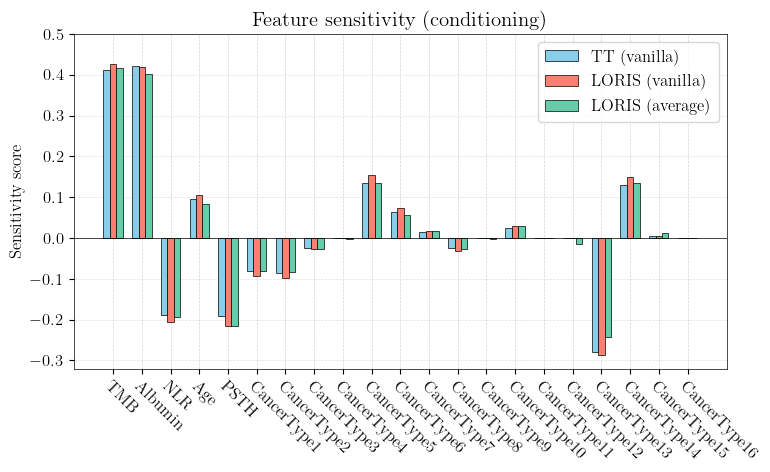

In [25]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (conditioning)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_cond.pdf'),
            bbox_inches='tight')
plt.show()

Marginalizing variables

In [26]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

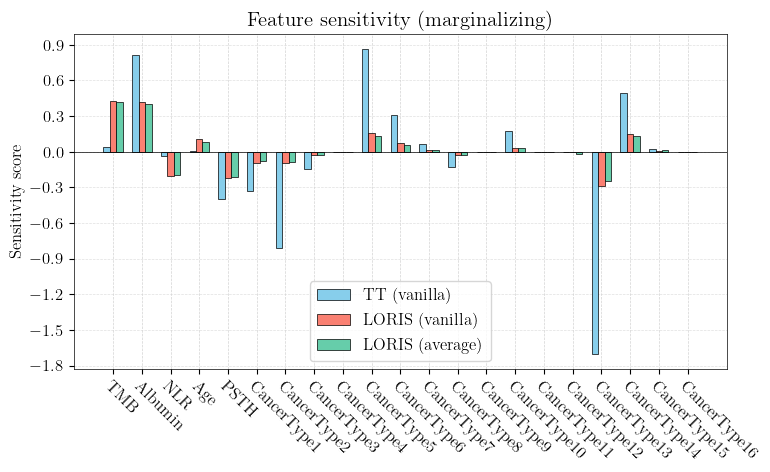

In [27]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (marginalizing)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower center')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.3)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_marg.pdf'),
            bbox_inches='tight')
plt.show()

Recovering LR coefficiets from the TT

In [28]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_coeffs(feat, lr_avg_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_coeffs(feat, tt_model, xt_train,
                                                featuresNA, scalers_train))

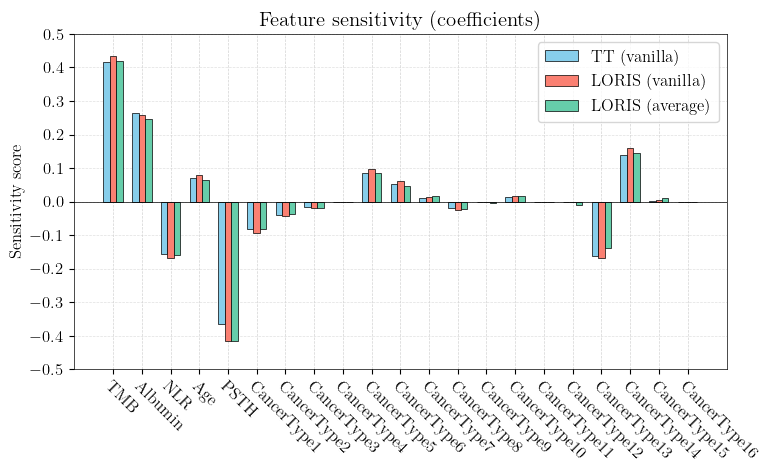

In [29]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
            bbox_inches='tight')
plt.show()

## Monotonic plots

In [30]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = 'Chowell_train' # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

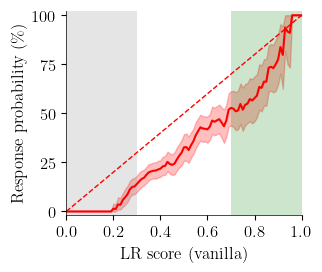

In [31]:
response_curve(lr_van_model, xt_train, yt_train, xlabel='LR score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_van.pdf'),
            bbox_inches='tight')
plt.show()

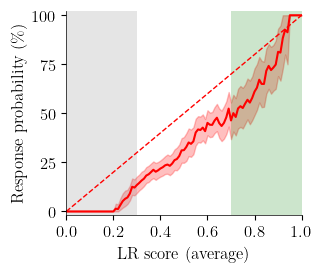

In [32]:
response_curve(lr_avg_model, xt_train, yt_train, xlabel='LR score (average)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_avg.pdf'),
            bbox_inches='tight')
plt.show()

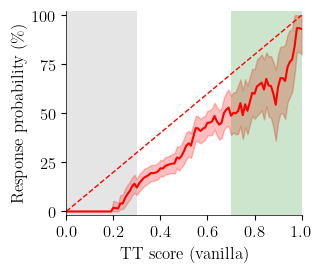

In [33]:
response_curve(tt_model, xt_train, yt_train, xlabel='TT score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_tt.pdf'),
            bbox_inches='tight')
plt.show()